#Imports

In [16]:
import warnings
warnings.filterwarnings('ignore')


import pandas as pd
import numpy as np
from plotnine import *

from sklearn.preprocessing import StandardScaler, OneHotEncoder #Z-score variables

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.cluster import DBSCAN
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

from sklearn.compose import make_column_transformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import silhouette_score
from sklearn.metrics import accuracy_score, confusion_matrix,\
 f1_score, recall_score, precision_score, roc_auc_score

import scipy.cluster.hierarchy as sch
from matplotlib import pyplot as plt

# Data Set 1


##Data Processing

In [2]:
data = pd.read_csv("https://raw.githubusercontent.com/cmparlettpelleriti/CPSC392ParlettPelleriti/master/Data/HW3_behavioral.csv")
data.head()
data.dropna(inplace = True)
data.reset_index(inplace = True, drop = True)
predictors = ["gender", "age", "current_income", "time_spent_browsing", "prop_ads_clicked", "longest_read_time", "length_of_subscription", "monthly_visits"]
continous = ["age","current_income", "time_spent_browsing", "prop_ads_clicked", "longest_read_time", "length_of_subscription", "monthly_visits"]
X = data[predictors]

z = make_column_transformer((StandardScaler(), continous),
                            (OneHotEncoder(), ["gender"]),
                            remainder = "passthrough")

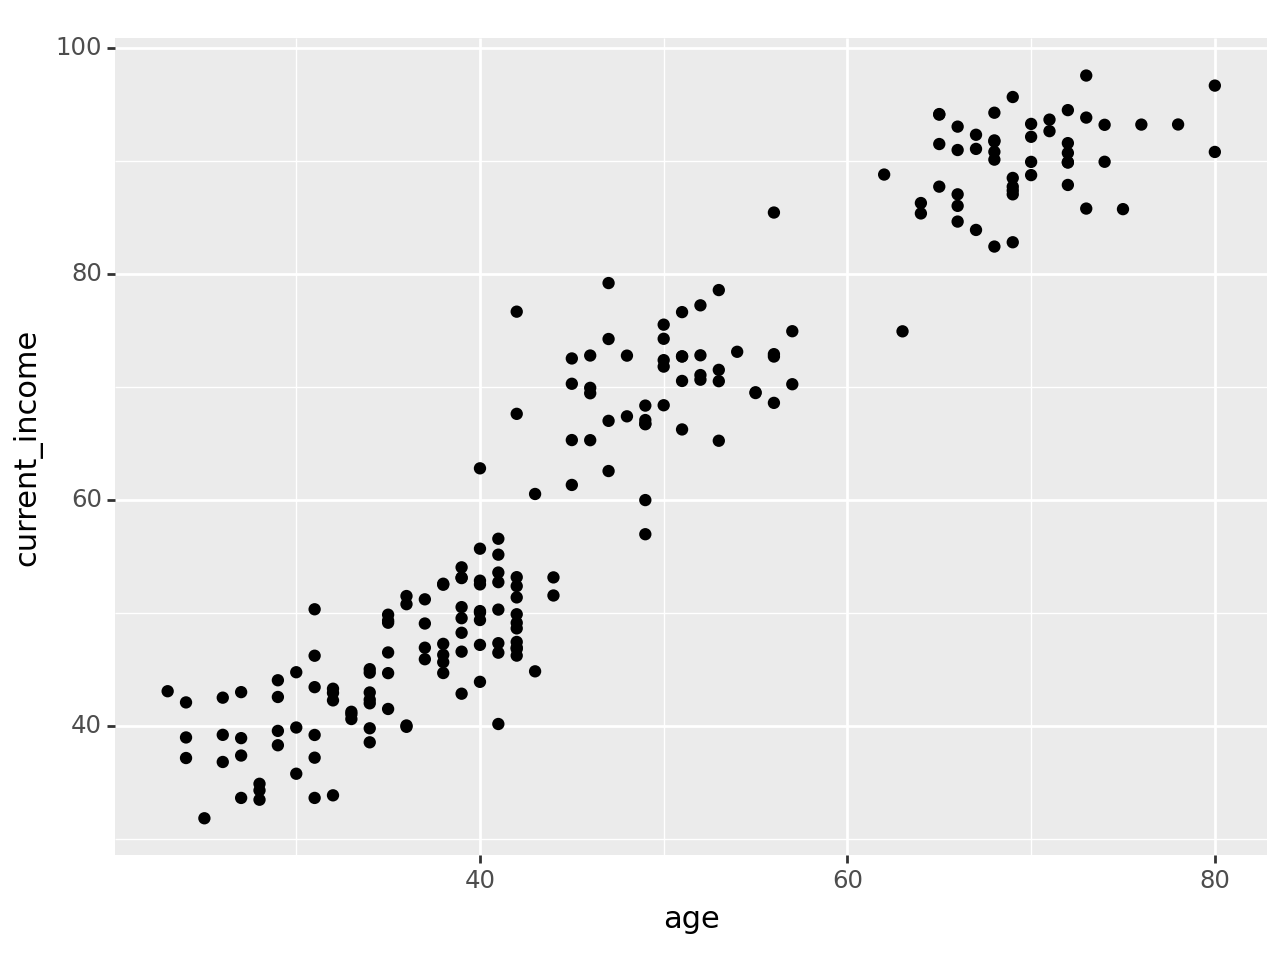

<Figure Size: (640 x 480)>

In [54]:
ggplot(data, aes(x = "age", y = "current_income")) + geom_point() #linear
#ggplot(data, aes(x = "current_income", y = "length_of_subscription")) + geom_point() # 4 clusters
#ggplot(data, aes(x = "time_spent_browsing", y = "prop_ads_clicked")) + geom_point() # 2ish clusters
# ggplot(data, aes(x = "age", y = "monthly_visits")) + geom_point() #linear
# ggplot(data, aes(x = "current_income", y = "monthly_visits")) + geom_point() #linear with clusters


## Model Testing

In [ ]:
#gmm = GaussianMixture(n_components = 3)
#pipe = Pipeline([("z", z), ("clust", gmm)])
#labels = pipe.fit_predict(X)
#print(silhouette_score(X[continous], pipe.predict(X[predictors])))

0.5453691627265875


In [ ]:
#km = KMeans(n_clusters = 4)
#pipe = Pipeline([("z", z), ("clust", km)])
#labels = pipe.fit_predict(X)
#print(silhouette_score(X[continous], pipe.predict(X[predictors])))

0.6055867462560669


In [ ]:
#db = DBSCAN(eps = 0.70, min_samples = 10)
#pipe = Pipeline([("z", z), ("clust", db)])
#labels = pipe.fit_predict(X)
#X["clusters"] = labels
#print(silhouette_score(X[continous], X["clusters"]))

0.07683919185821196


In [3]:
hac = AgglomerativeClustering(affinity = "euclidean",
                             linkage = "ward",
                             n_clusters = 4)
pipe = Pipeline([("z", z), ("clust", hac)])
labels = pipe.fit_predict(X)
print(silhouette_score(X[continous], labels))

0.614260104940831


I choose Agglormerative Clustering because it has the highest silhouette score out of all of the clustering models with each of their respective hyperparameters. Agglormerative Clustering had a silhouette score of 0.614, while KMeans had 0.605, GuassianMixture with 0.543, and DBSCAN with 0.076. In addition, the hyperparameter of 4 clusters for HAC had the best silhouette score as it goes down when increasing higher than 4 or decreasing lower than 4.

## PCA Dimensionality Reduction

In [4]:
pca = PCA()

pipePCA = Pipeline([
    ("z", z),
    ("pca", pca)
])
X_Pca = pipePCA.fit_transform(X)

# scree/cumvar plot
pcaDF = pd.DataFrame({"expl_var" : pipePCA.named_steps["pca"].explained_variance_ratio_,
                      "pc": range(1,12),
                      "cum_var": pipePCA.named_steps["pca"].explained_variance_ratio_.cumsum()})


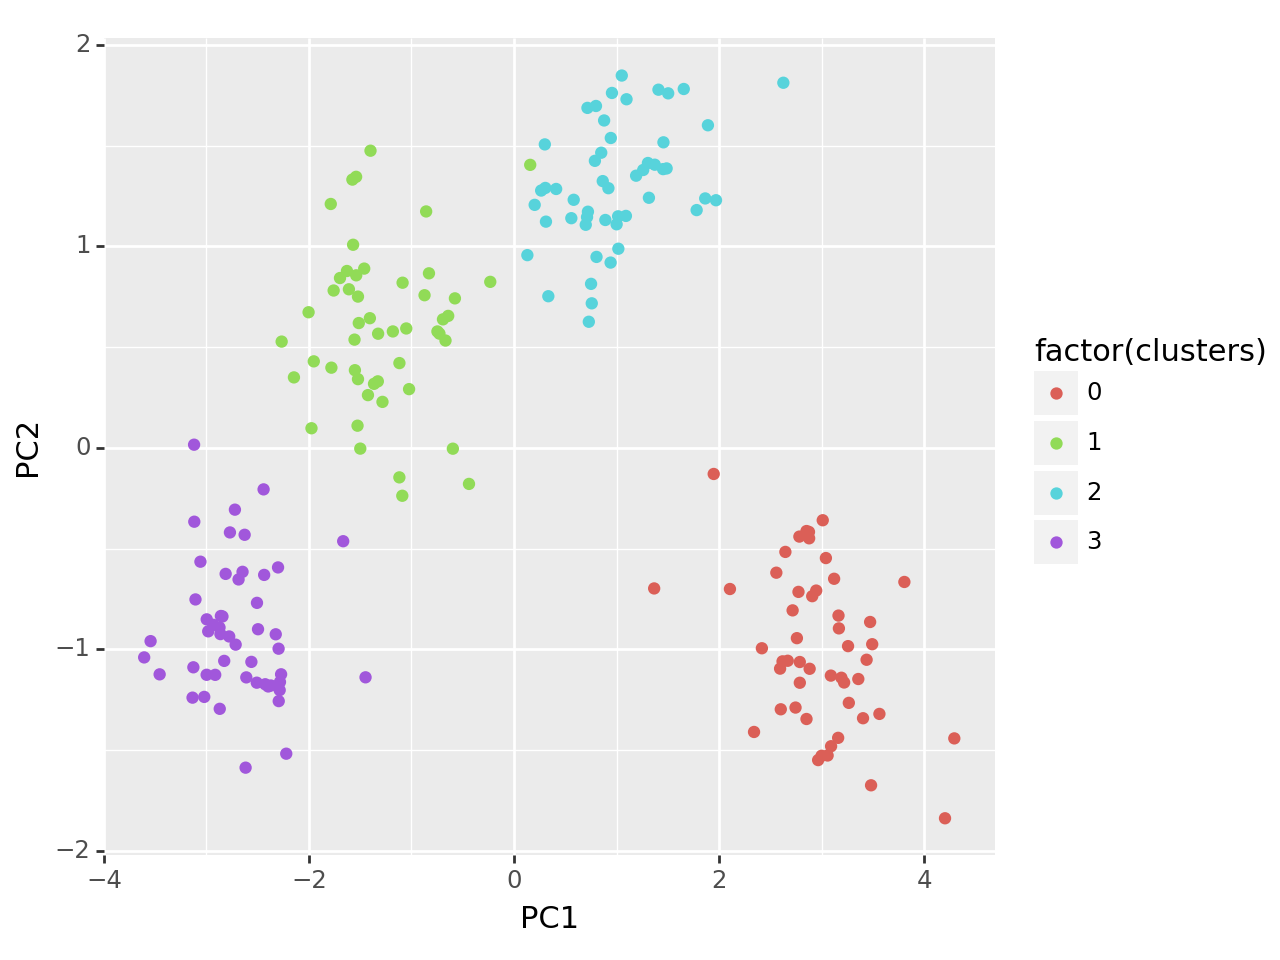

<Figure Size: (640 x 480)>

In [5]:
pca_DF = pd.DataFrame({
    "PC1": X_Pca[:, 0],
    "PC2": X_Pca[:, 1],
    "clusters": labels
})
(ggplot(pca_DF, aes(x='PC1', y='PC2', color='factor(clusters)')) + geom_point())

In [ ]:
# Scree/Elbow Plot
"""
print(ggplot(pcaDF, aes(x = "pc", y = "expl_var")) + geom_line() + geom_point() +
 theme_minimal() + labs(x = "PCs", y = "Proportion of Explained Variance", title = "Scree Plot"))

pcaDF0 = pd.concat([pcaDF, pd.DataFrame({"pc": [0], "cum_var": [0]})]) # add 0,0 for reference

print(ggplot(pcaDF0, aes(x = "pc", y = "cum_var")) + geom_line() +
 geom_point() + geom_hline(yintercept = 0.95, color = "red", linetype = "dashed") +
 theme_minimal() + labs(x = "Number of PCs", y = "Cumulative Proportion of Explained Variance", title = "Cumulative Variance Plot"))
 """

## Additional Information

Means of each variable for each cluster

In [6]:
cluster_means = X[continous].groupby(labels).mean()
cluster_means

,age,current_income,time_spent_browsing,prop_ads_clicked,longest_read_time,length_of_subscription,monthly_visits
0,69.38,90.1498,645.677263,0.228305,244.238716,698.608170,45.221277
1,40.04,49.8878,343.073691,0.067415,142.826191,404.426234,21.083926
2,49.88,70.2402,604.959459,0.151891,206.024646,299.507200,33.263248
3,30.70,40.7134,199.091869,0.051094,89.714911,660.924034,10.668075


#Data Set #2

## Preprocessing & Dendrogram

In [43]:
data2 = pd.read_csv("https://raw.githubusercontent.com/cmparlettpelleriti/CPSC392ParlettPelleriti/master/Data/HW3_topics.csv")


In [39]:
def plot_dendrogram(pipe, **kwargs):

    if "model" not in pipe.named_steps.keys():
        raise NameError("Your clustering pipeline step must be called 'model' for this function to work.")

    # create the counts of samples under each node
    counts = np.zeros(pipe.named_steps["model"].children_.shape[0])
    n_samples = len(pipe.named_steps["model"].labels_)
    for i, merge in enumerate(pipe.named_steps["model"].children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [pipe.named_steps["model"].children_, pipe.named_steps["model"].distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    sch.dendrogram(linkage_matrix, **kwargs)



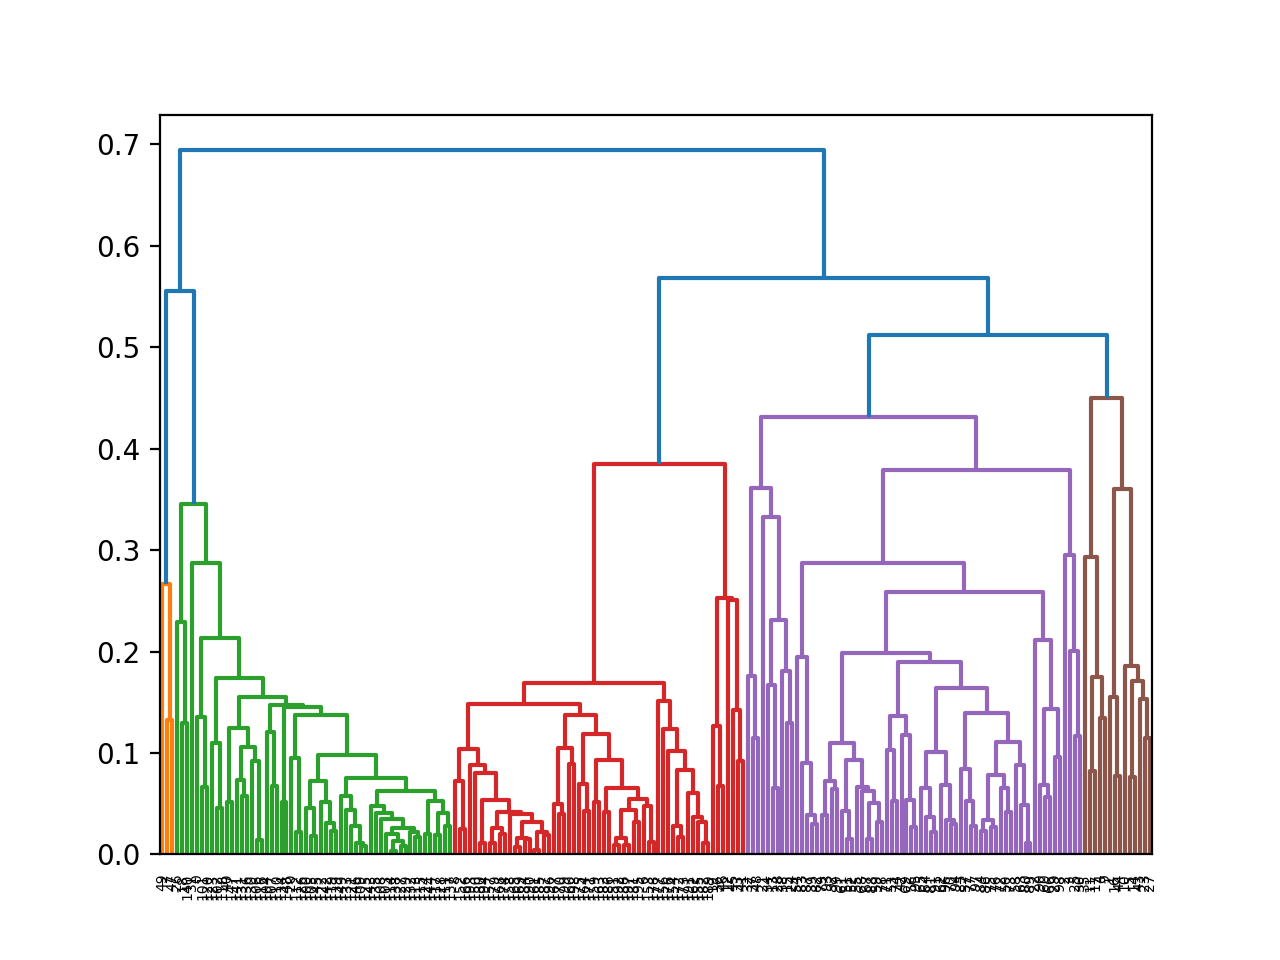

In [40]:
features = ["Stocks", "Productivity", "Fashion", "Celebrity", "Cryptocurrency", "Science", "Technology", "SelfHelp", "Fitness", "AI"]
X2= data2[features]
hac = AgglomerativeClustering(affinity = "cosine",
                             linkage = "average",
                             distance_threshold= 0,
                             n_clusters = None)
pipe2 = Pipeline([("model", hac)])

labels2 = pipe2.fit_predict(X2)

plot_dendrogram(pipe2, color_threshold= 0.45)


## Model Fitting

In [ ]:
hac_refit = AgglomerativeClustering(affinity = "cosine",
                             linkage = "average",
                             n_clusters = 5)
pipe2_refit = Pipeline([("model", hac_refit)])

labels2_refit = pipe2_refit.fit_predict(X2)
X2["clusters"] = labels2_refit


## Additional Information

In [46]:
cluster_means2 = X2[features].groupby(labels2_refit).mean()
cluster_means2

,Stocks,Productivity,Fashion,Celebrity,Cryptocurrency,Science,Technology,SelfHelp,Fitness,AI
0,3.238095,3.666667,5.142857,2.714286,3.809524,18.190476,33.476190,2.238095,3.666667,33.523810
1,5.564626,6.571429,6.367347,7.278912,2.367347,3.428571,2.591837,8.217687,4.394558,5.027211
2,4.000000,3.241379,1.655172,3.137931,4.724138,15.068966,27.758621,4.551724,3.896552,26.517241
3,1.000000,0.000000,16.500000,13.000000,0.500000,3.000000,0.500000,6.000000,1.500000,1.000000
4,2.000000,54.000000,4.000000,0.000000,3.000000,5.000000,0.000000,40.000000,3.000000,5.000000
